# Chapter 3: Fluid Characterization and PVT Modeling

Real reservoir fluids contain heavy hydrocarbon fractions that cannot be represented by
individual pure components. This chapter demonstrates:

- **Plus-fraction characterization**: Splitting C7+ into pseudo-components using TBP data
- **Phase envelope**: Mapping the two-phase boundary of a gas condensate
- **Liquid dropout (CVD)**: How liquid volume changes with pressure depletion
- **GOR and Bo**: Key PVT parameters for production forecasting

We model a gas condensate fluid typical of deep-water or HP/HT reservoirs.

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch03_fluid_characterization_figures.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# jneqsim is bound to the source JVM in the setup cell.

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

## 3.1 Creating a Gas Condensate Fluid with Plus Fractions

The fluid includes light gases (N₂, CO₂, C1–C5) and heavier TBP fractions
(C7 through C10+) characterized by molar mass and specific gravity.

In [3]:
def create_gas_condensate(T_K, P_bara):
    """Create a gas condensate fluid with TBP plus fractions."""
    fluid = SystemSrkEos(T_K, P_bara)
    fluid.addComponent("nitrogen", 0.34)
    fluid.addComponent("CO2", 3.59)
    fluid.addComponent("methane", 67.42)
    fluid.addComponent("ethane", 7.46)
    fluid.addComponent("propane", 3.05)
    fluid.addComponent("i-butane", 0.85)
    fluid.addComponent("n-butane", 1.68)
    fluid.addComponent("i-pentane", 0.63)
    fluid.addComponent("n-pentane", 0.74)
    fluid.addComponent("n-hexane", 1.10)
    fluid.addTBPfraction("C7", 1.0, 92.0 / 1000.0, 0.7324)
    fluid.addTBPfraction("C8", 1.15, 104.0 / 1000.0, 0.7602)
    fluid.addTBPfraction("C9", 0.95, 119.0 / 1000.0, 0.7824)
    fluid.addTBPfraction("C10", 5.0, 230.0 / 1000.0, 0.85)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid

# Test flash
fluid_test = create_gas_condensate(273.15 + 90.0, 200.0)
ops_test = ThermodynamicOperations(fluid_test)
ops_test.TPflash()
fluid_test.initProperties()
print(f"Number of phases: {fluid_test.getNumberOfPhases()}")
print(f"Total density: {fluid_test.getDensity('kg/m3'):.2f} kg/m³")
print(f"Number of components: {fluid_test.getNumberOfComponents()}")

Number of phases: 2
Total density: 278.04 kg/m³
Number of components: 14


## 3.2 Figure 1 — Molecular Weight Distribution

After characterization, the plus fractions are split into pseudo-components.
This bar chart shows the molecular weight of each component in the fluid.

ch03_fluid_characterization_figures.ipynb:cell6:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


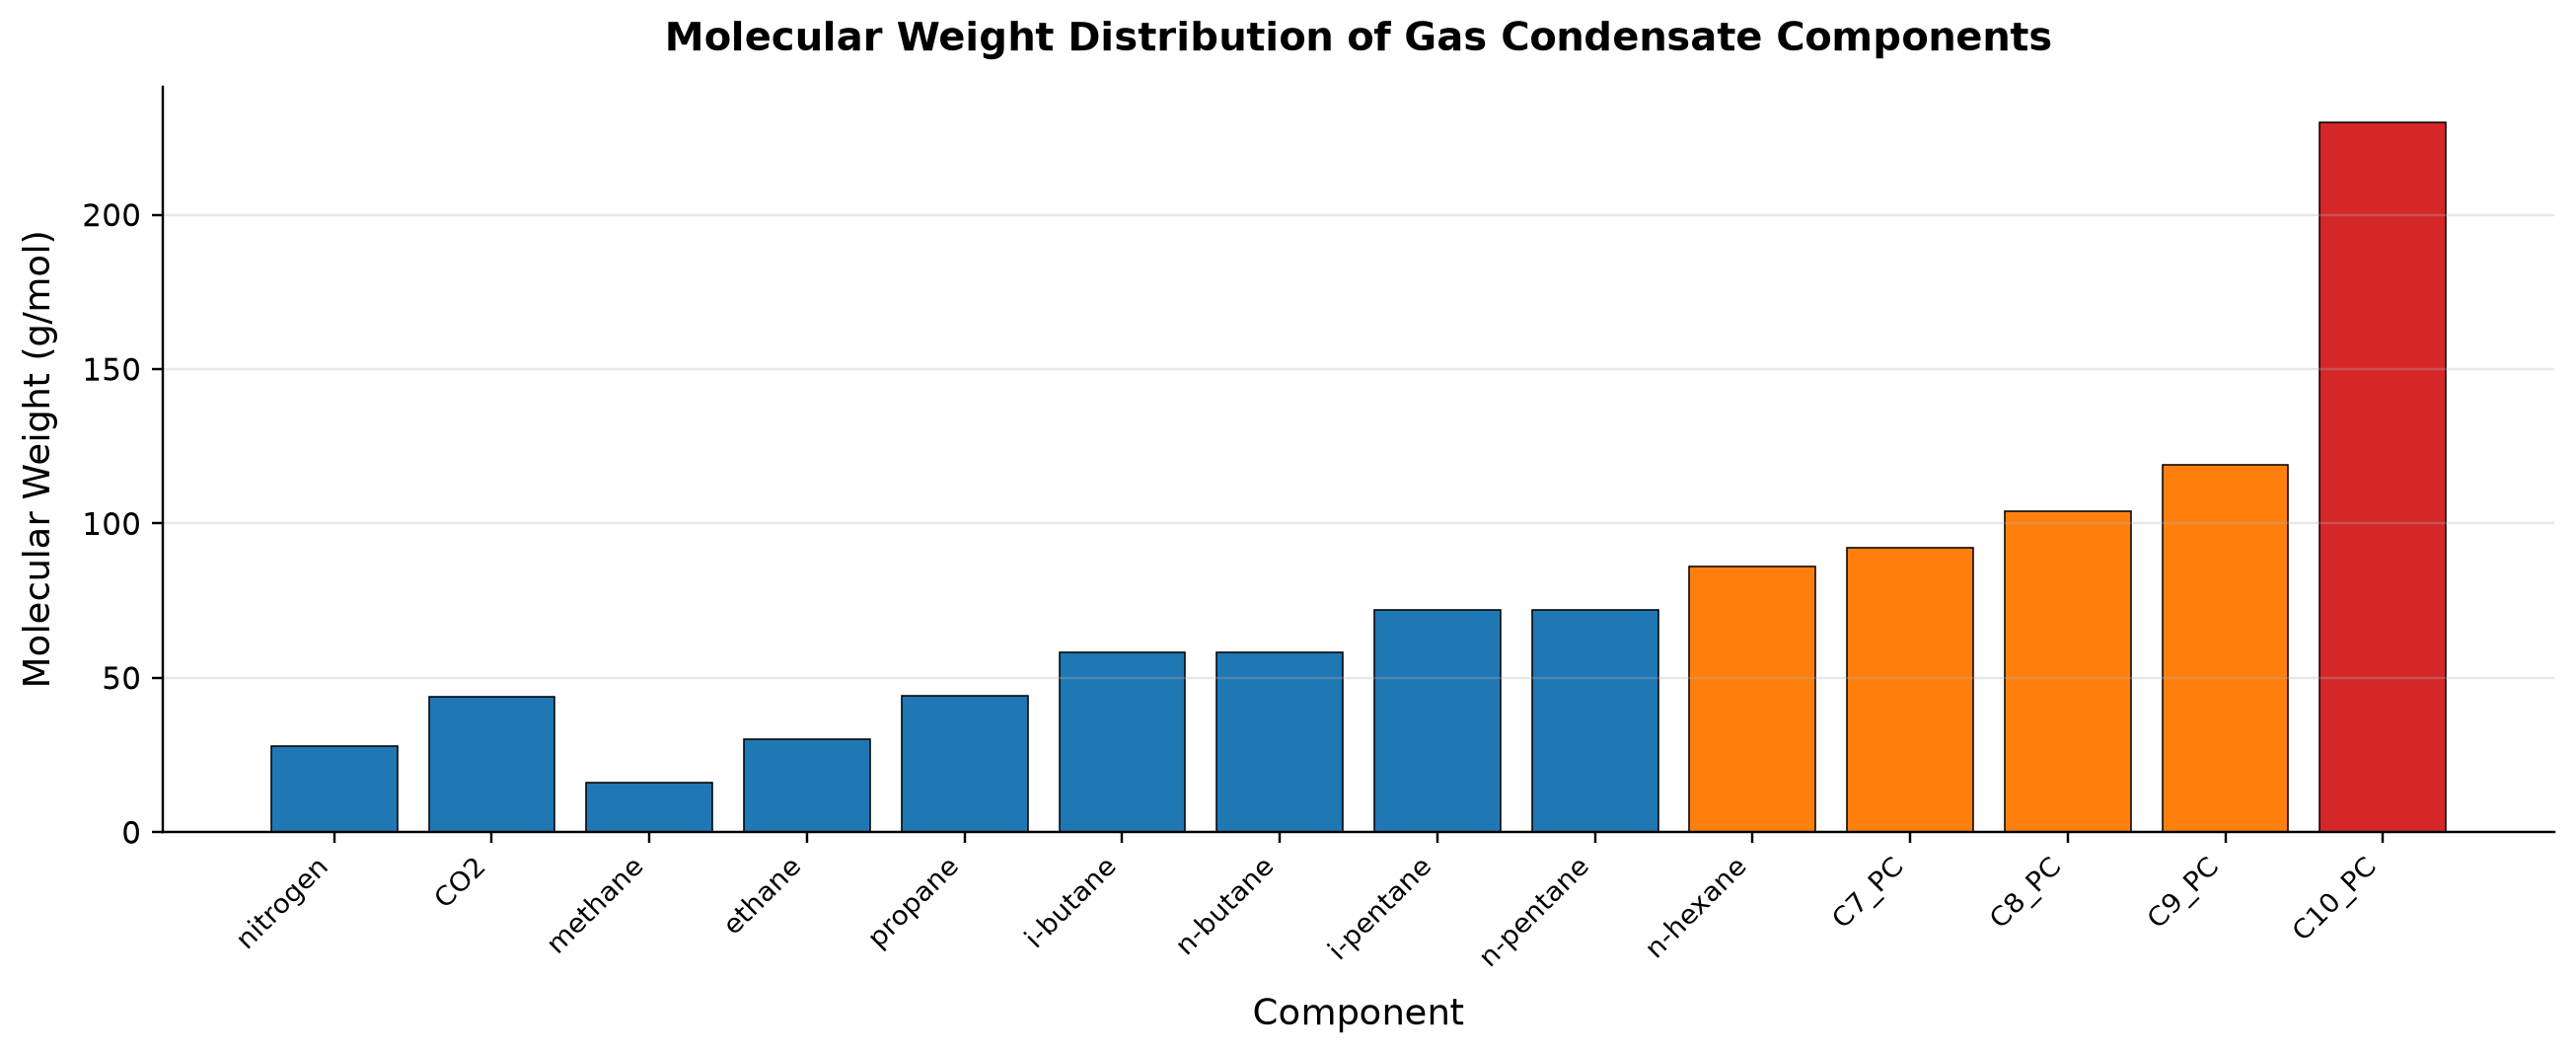

In [4]:
fluid_mw = create_gas_condensate(273.15 + 90.0, 200.0)
ops_mw = ThermodynamicOperations(fluid_mw)
ops_mw.TPflash()
fluid_mw.initProperties()

n_comp = fluid_mw.getNumberOfComponents()
comp_names = []
mol_weights = []
mole_fracs = []

for i in range(n_comp):
    name = fluid_mw.getComponent(i).getComponentName()
    mw = fluid_mw.getComponent(i).getMolarMass() * 1000.0  # kg/mol -> g/mol
    zf = fluid_mw.getComponent(i).getz()
    comp_names.append(name)
    mol_weights.append(mw)
    mole_fracs.append(zf)

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(comp_names))
colors = ['#1f77b4' if mw < 80 else '#ff7f0e' if mw < 150 else '#d62728' for mw in mol_weights]
ax.bar(x_pos, mol_weights, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(comp_names, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Component', fontsize=12)
ax.set_ylabel('Molecular Weight (g/mol)', fontsize=12)
ax.set_title('Molecular Weight Distribution of Gas Condensate Components', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig01_molecular_weight_distribution.png', dpi=220, bbox_inches='tight')
plt.show()

**Executed-figure discussion.** Molecular Weight spans 16.04–230 g/mol across the plotted cases.

Heavy-end characterization distributes an unresolved fraction into pseudo-components with assigned molecular weights and densities. The assumed tail controls liquid density, vapor–liquid equilibrium and predicted condensate recovery even when the total plus fraction is unchanged. Constrain the distribution with measured plus-fraction molecular weight, density and boiling data; retain the characterization settings with the fluid model.


## 3.3 Figure 2 — Phase Envelope (PT Diagram)

The phase envelope shows the boundary between single-phase and two-phase regions.
For a gas condensate, the cricondentherm and cricondenbar define the maximum
temperature and pressure at which two phases can coexist.

dewT: 48 physical continuation points; 1 sentinel entries excluded
bubT: 0 physical continuation points; 1 sentinel entries excluded


ch03_fluid_characterization_figures.ipynb:cell8:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


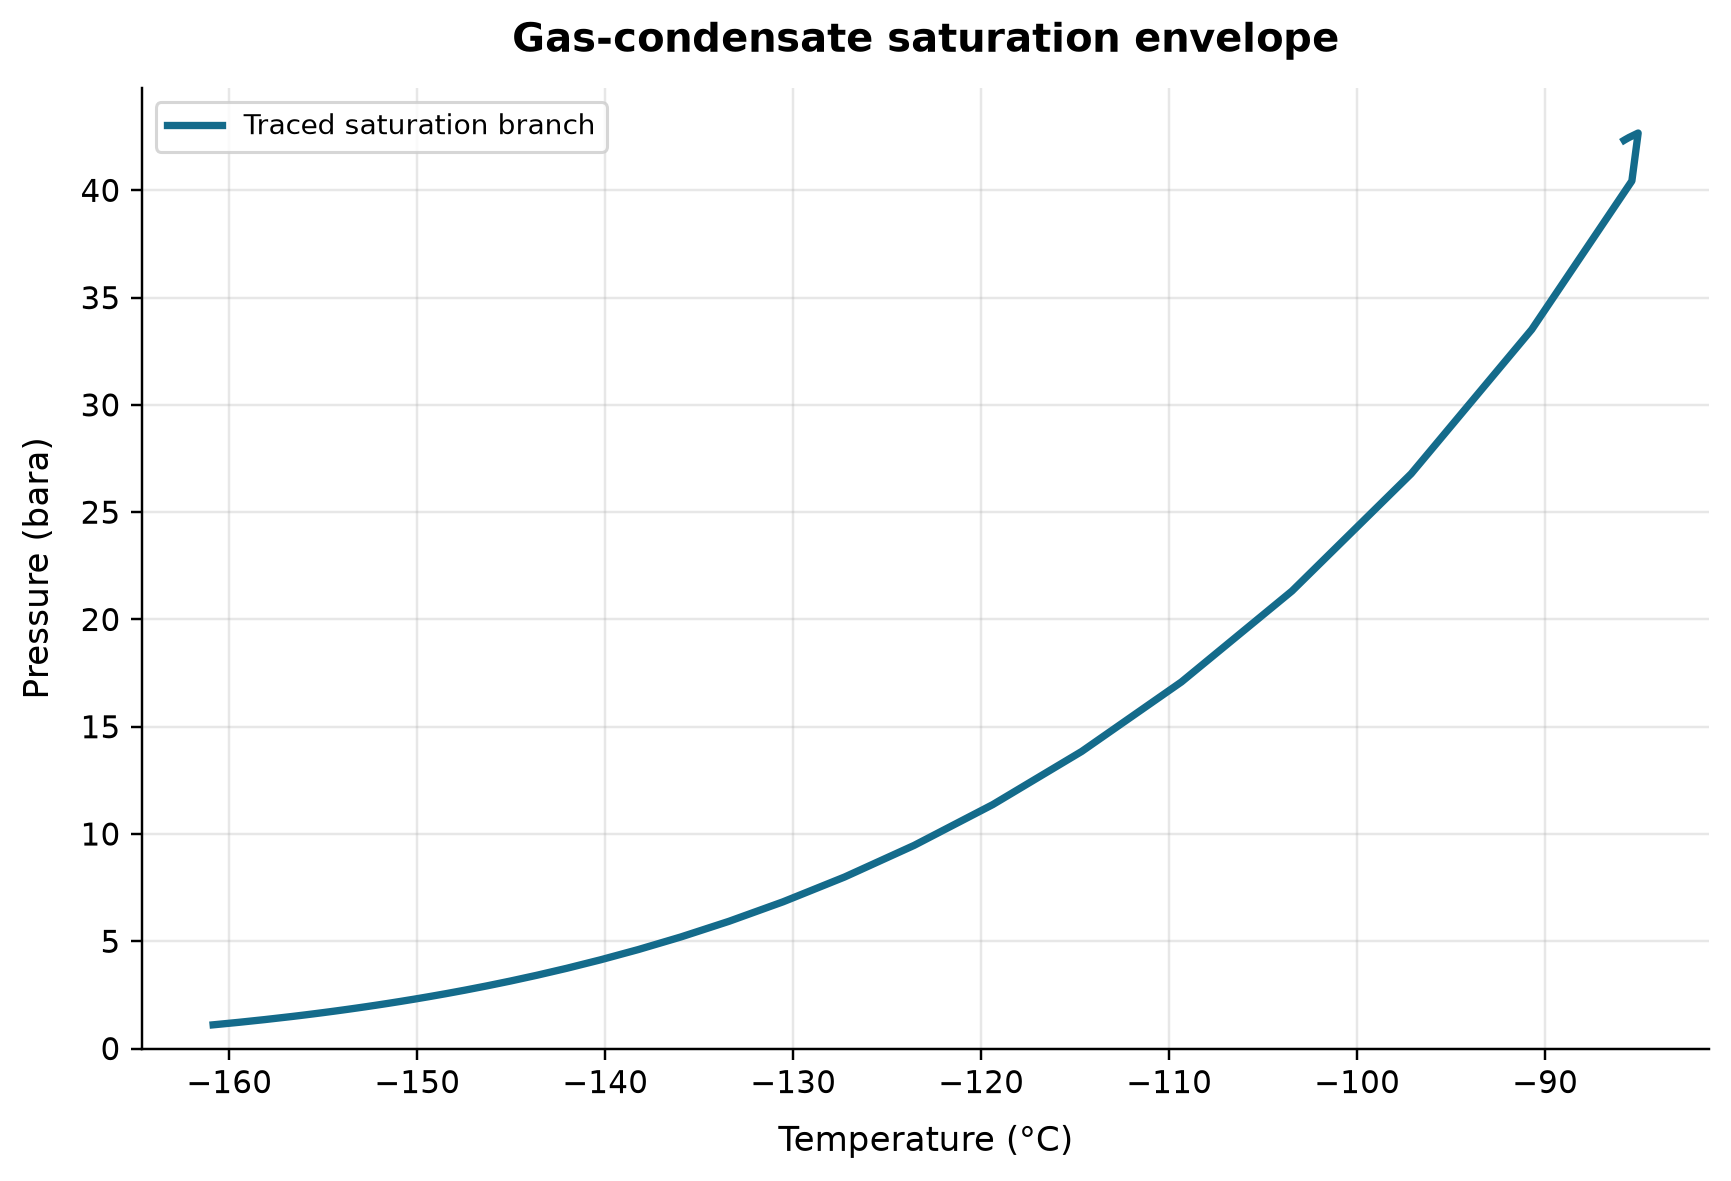

In [5]:
fluid_env = create_gas_condensate(273.15 + 90.0, 200.0)
fluid_env.setMultiPhaseCheck(True)
ops_env = ThermodynamicOperations(fluid_env)
ops_env.calcPTphaseEnvelope(True, 1.0)
branches = []
for t_key, p_key in [("dewT", "dewP"), ("bubT", "bubP")]:
    raw_t, raw_p = np.asarray(ops_env.get(t_key), dtype=float), np.asarray(ops_env.get(p_key), dtype=float)
    valid = np.isfinite(raw_t) & np.isfinite(raw_p) & (raw_t > 0) & (raw_p > 0)
    print(f"{t_key}: {valid.sum()} physical continuation points; {(~valid).sum()} sentinel entries excluded")
    if valid.sum() >= 2:
        branches.append((raw_t[valid] - 273.15, raw_p[valid]))
assert branches, "Envelope solver returned no finite physical branch"
# Continuation getter labels can be swapped: the dew branch contains the cricondentherm.
branches.sort(key=lambda branch: np.max(branch[0]), reverse=True)
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, (temperature, pressure) in enumerate(branches):
    label = ("Dew branch" if i == 0 else "Bubble branch") if len(branches) == 2 else "Traced saturation branch"
    ax.plot(temperature, pressure, linewidth=2.4, label=label)
ax.set(xlabel="Temperature (°C)", ylabel="Pressure (bara)", title="Gas-condensate saturation envelope")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig02_phase_envelope_condensate.png", dpi=220, bbox_inches="tight")
plt.show()


**Executed-figure discussion.** Traced saturation branch: pressure spans 1.105–42.67 bara across the plotted cases.

Heavy hydrocarbons extend the saturation envelope and make gas-condensate phase behavior sensitive to the uncertain C7+ tail. A traced dew branch can be useful even when the solver cannot produce a complete bubble branch; an absent branch must not be replaced by an invented curve. Validate dew pressure and liquid dropout against laboratory data and distinguish calculated branch coverage from the full physical envelope.


## 3.4 Figure 3 — Liquid Dropout Curve (CVD-like)

During pressure depletion (constant volume depletion), liquid condenses from
the gas phase below the dew point. We simulate this by flashing at decreasing
pressures at reservoir temperature and tracking the liquid phase fraction.

Maximum equilibrium liquid fraction: 100.00% at 400 bara


ch03_fluid_characterization_figures.ipynb:cell10:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


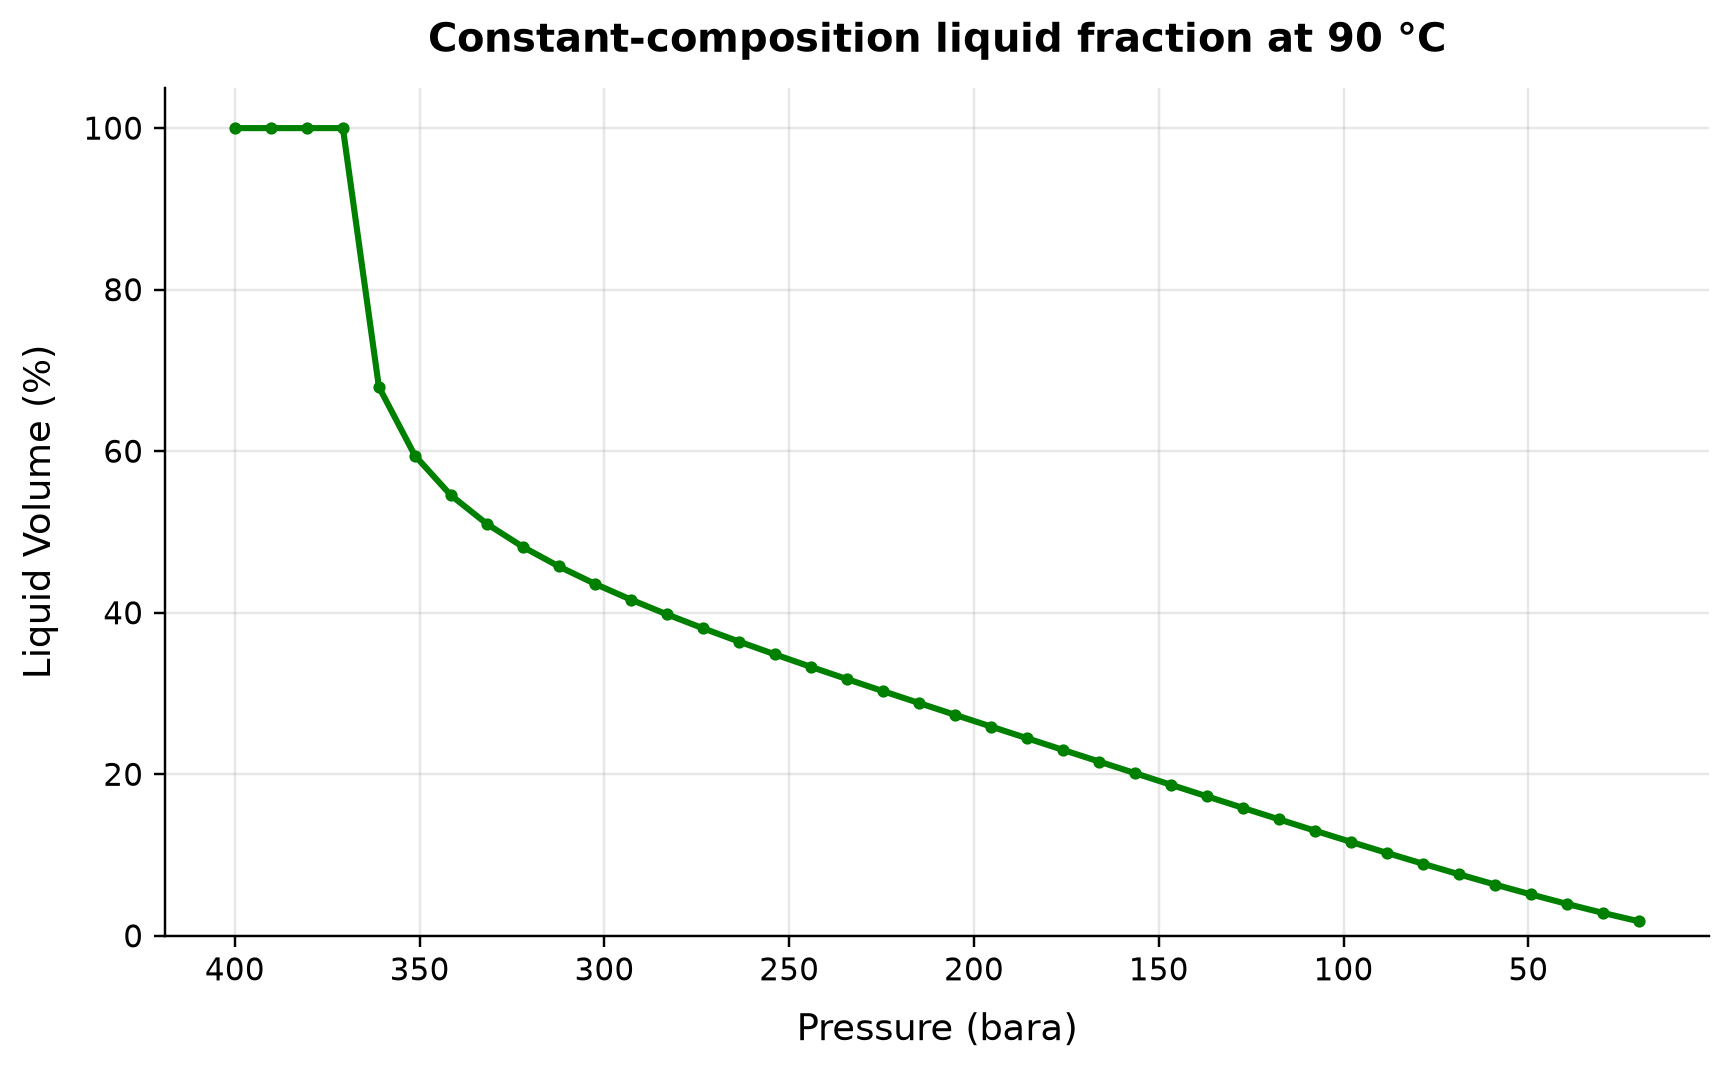

In [6]:
T_res_K = 273.15 + 90.0
pressures_cvd = np.linspace(400, 20, 40)
liquid_vol_pct = []

for P in pressures_cvd:
    fluid = create_gas_condensate(T_res_K, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    n_phases = fluid.getNumberOfPhases()
    if fluid.hasPhaseType("oil"):
        # Liquid volume fraction as percentage
        oil_vol = fluid.getPhase("oil").getVolume("m3")
        total_vol = fluid.getVolume("m3")
        liquid_vol_pct.append(100.0 * oil_vol / total_vol)
    else:
        liquid_vol_pct.append(0.0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pressures_cvd, liquid_vol_pct, 'g-o', markersize=3, linewidth=2)
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Liquid Volume (%)', fontsize=12)
ax.set_title('Constant-composition liquid fraction at 90 °C', fontsize=13)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig03_liquid_dropout_curve.png', dpi=220, bbox_inches='tight')
plt.show()

max_dropout = max(liquid_vol_pct)
max_p_idx = liquid_vol_pct.index(max_dropout)
print(f"Maximum equilibrium liquid fraction: {max_dropout:.2f}% at {pressures_cvd[max_p_idx]:.0f} bara")

**Executed-figure discussion.** Liquid Volume spans 1.783–100 % across the plotted cases.

At fixed composition, successive equilibrium flashes show how the liquid volume changes as pressure traverses the two-phase region. A fixed-composition pressure sweep does not reproduce a constant-volume depletion experiment, which removes gas and changes the remaining composition. Use the curve as a phase-behavior screen; use NeqSim’s actual depletion experiment model when comparing with CVD laboratory data.


## 3.5 Figure 4 — Gas-Oil Ratio vs Pressure

The GOR increases as pressure drops below the saturation pressure,
because more gas is liberated from the liquid phase.

GOR range: 0.2 – 34.0 (vol/vol at conditions)


ch03_fluid_characterization_figures.ipynb:cell12:37: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


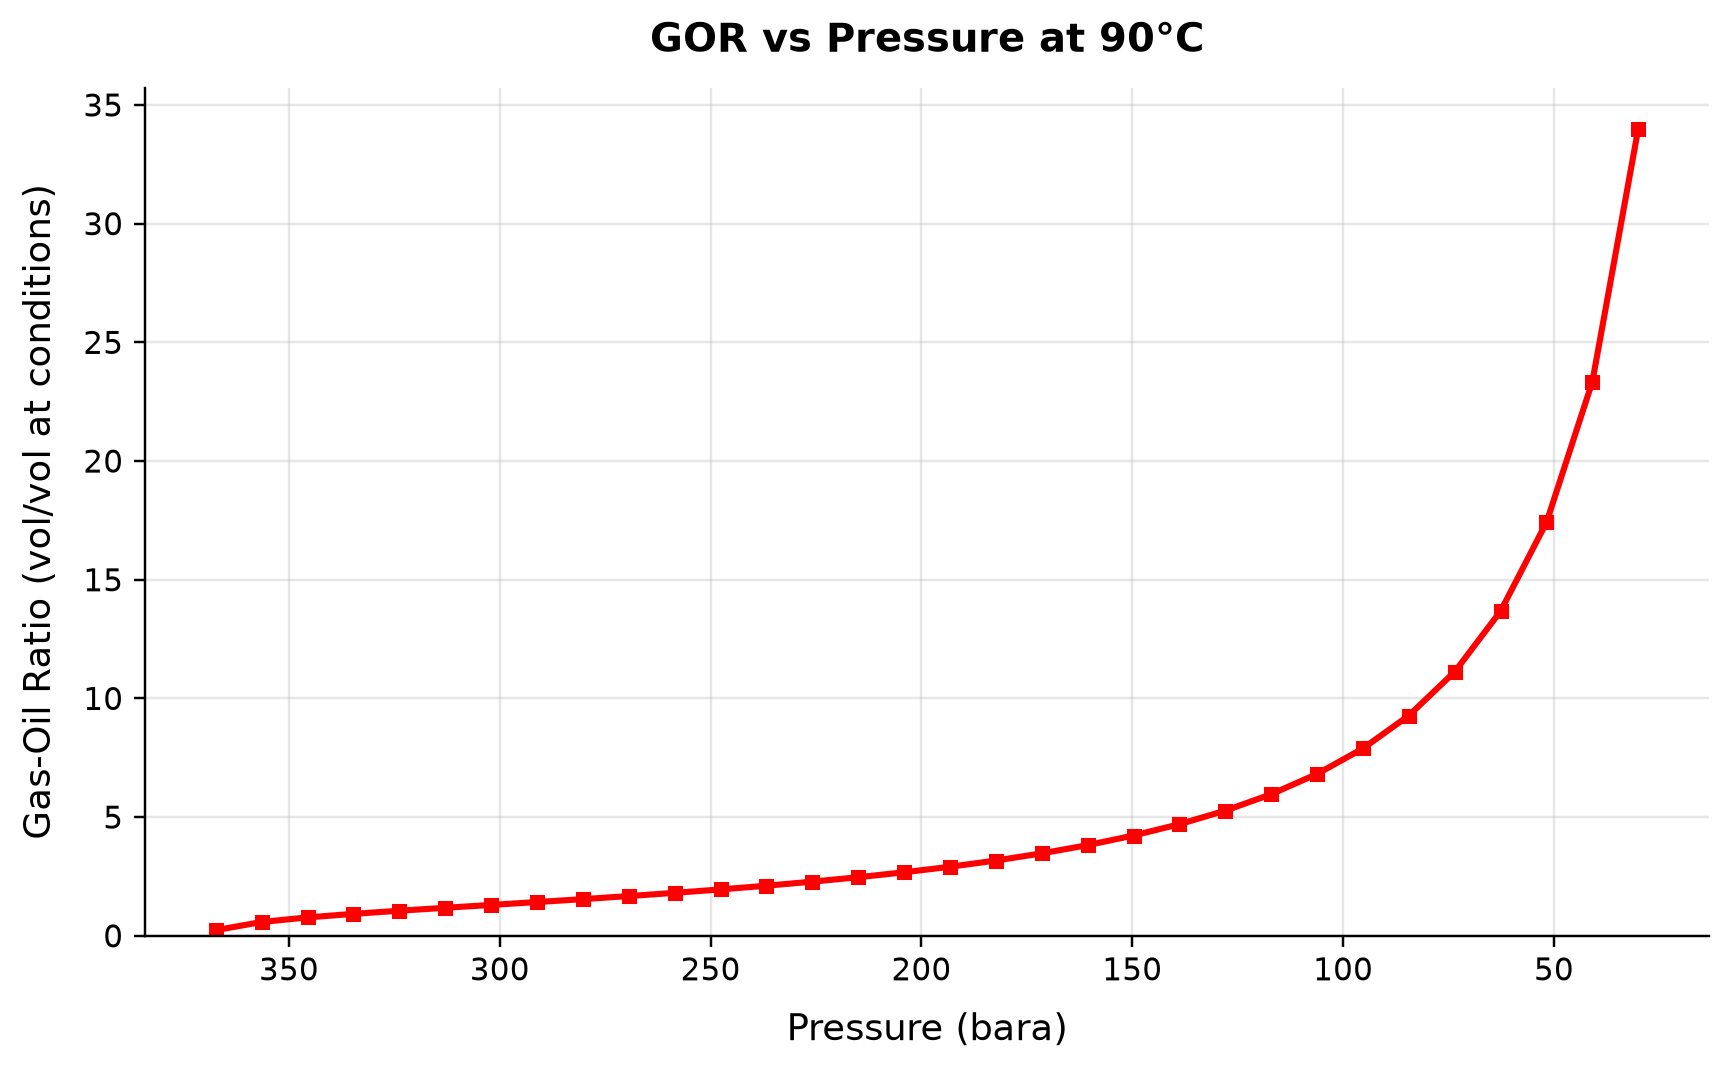

In [7]:
pressures_gor = np.linspace(400, 30, 35)
gor_values = []

for P in pressures_gor:
    fluid = create_gas_condensate(T_res_K, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    n_phases = fluid.getNumberOfPhases()
    if n_phases > 1 and fluid.hasPhaseType("oil") and fluid.hasPhaseType("gas"):
        gas_vol = fluid.getPhase("gas").getVolume("m3")
        oil_vol = fluid.getPhase("oil").getVolume("m3")
        if oil_vol > 1e-12:
            gor_values.append(gas_vol / oil_vol)
        else:
            gor_values.append(float('nan'))
    else:
        gor_values.append(float('nan'))

# Filter valid points
valid_idx = [i for i, g in enumerate(gor_values) if not np.isnan(g)]
p_valid = [pressures_gor[i] for i in valid_idx]
gor_valid = [gor_values[i] for i in valid_idx]

fig, ax = plt.subplots(figsize=(8, 5))
if len(p_valid) > 0:
    ax.plot(p_valid, gor_valid, 'r-s', markersize=4, linewidth=2)
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Gas-Oil Ratio (vol/vol at conditions)', fontsize=12)
ax.set_title('GOR vs Pressure at 90°C', fontsize=13)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig04_gor_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()
if len(gor_valid) > 0:
    print(f"GOR range: {min(gor_valid):.1f} – {max(gor_valid):.1f} (vol/vol at conditions)")

**Executed-figure discussion.** Gas-Oil Ratio spans 0.237–34.01 vol/vol at conditions across the plotted cases.

Pressure reduction transfers volatile components from the hydrocarbon liquid into the equilibrium gas phase. An equilibrium phase gas-to-oil ratio is sensitive to the chosen reference volumes and is not automatically the solution GOR reported by a separator or differential-liberation test. State the volume basis and separation procedure, and match those definitions before comparing with laboratory Rs or field GOR.


## 3.6 Figure 5 — Formation Volume Factor (Bo) vs Pressure

The oil formation volume factor Bo is the ratio of oil volume at reservoir conditions
to its volume at standard conditions. We approximate it using density ratios:

$$B_o = \frac{\rho_{\text{std}}}{\rho_{\text{res}}}$$

In [8]:
# Reference density at standard conditions (1.01325 bara, 15°C)
fluid_std = create_gas_condensate(273.15 + 15.0, 1.01325)
ops_std = ThermodynamicOperations(fluid_std)
ops_std.TPflash()
fluid_std.initProperties()

rho_std = None
if fluid_std.hasPhaseType("oil"):
    rho_std = fluid_std.getPhase("oil").getDensity("kg/m3")
    print(f"Oil density at std conditions: {rho_std:.1f} kg/m³")
else:
    rho_std = fluid_std.getDensity("kg/m3")
    print(f"Using total fluid density at std conditions: {rho_std:.1f} kg/m³")

Oil density at std conditions: 819.7 kg/m³


Bo range: 1.165 – 4.036


ch03_fluid_characterization_figures.ipynb:cell15:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


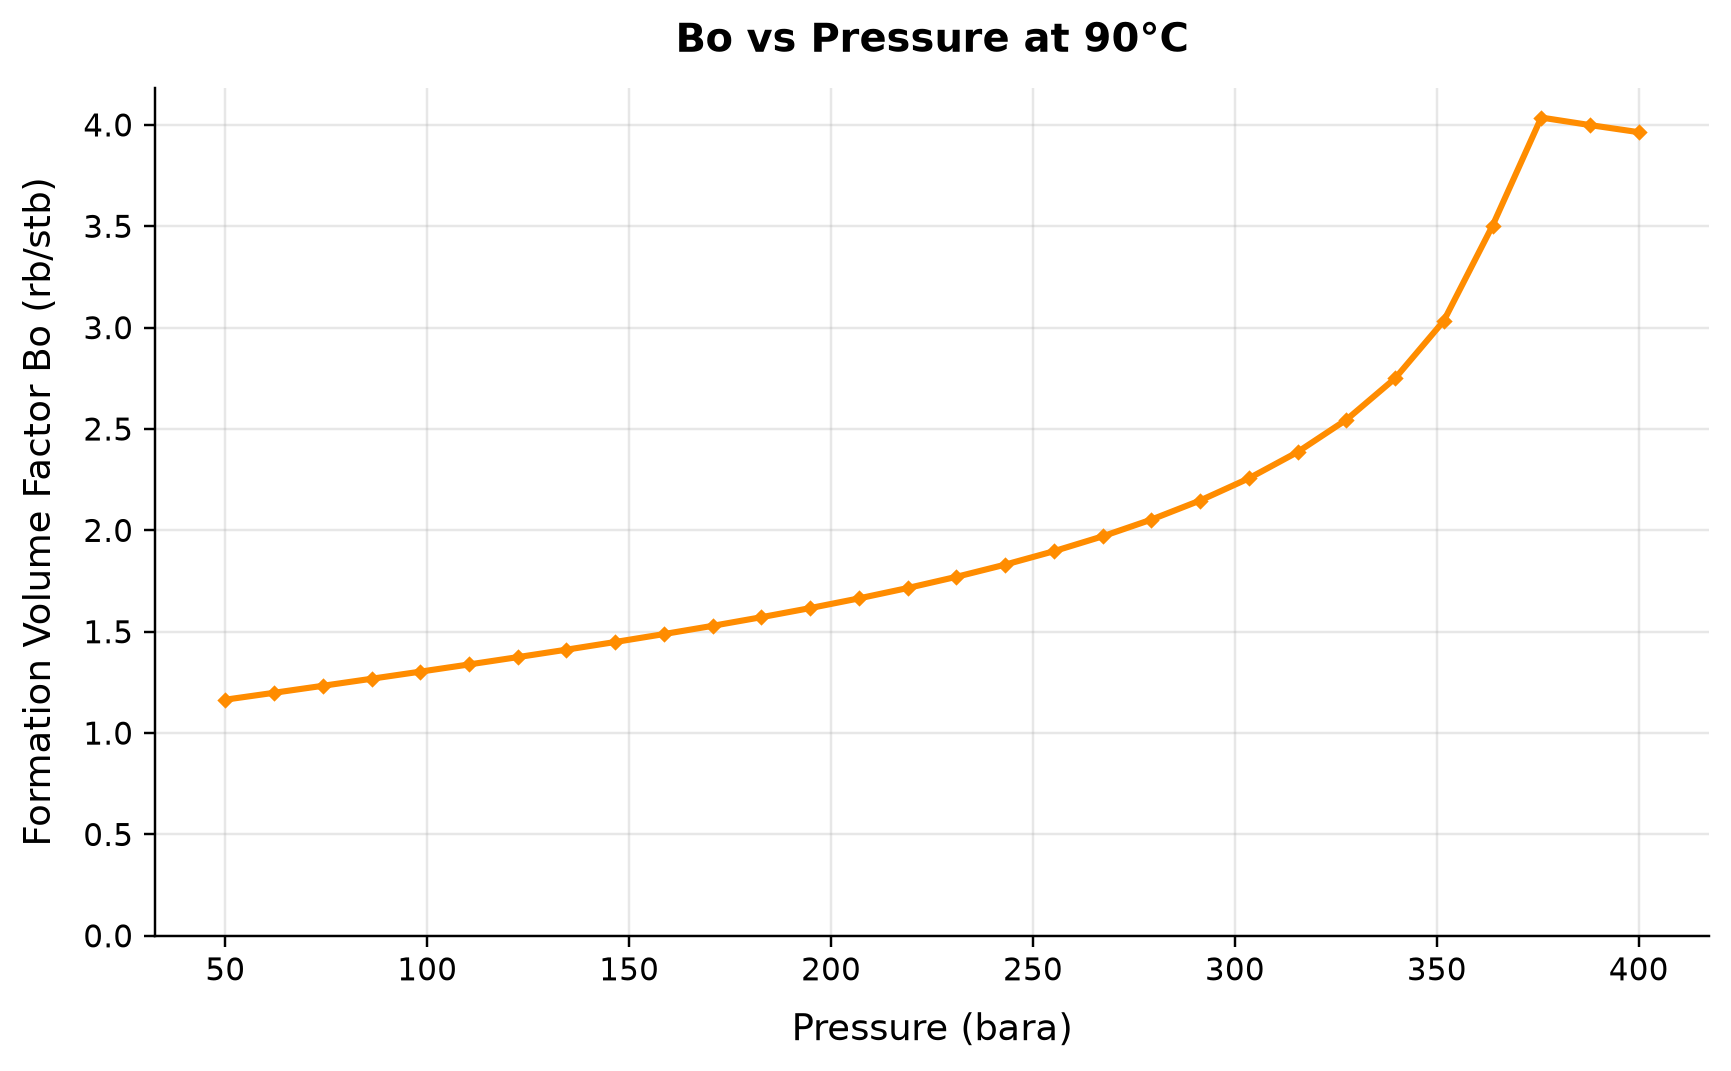

In [9]:
pressures_bo = np.linspace(50, 400, 30)
bo_values = []

for P in pressures_bo:
    fluid = create_gas_condensate(T_res_K, float(P))
    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    if not fluid.hasPhaseType("oil"):
        bo_values.append(float('nan'))
        continue
    # Flash the SAME reservoir liquid sample to stock-tank conditions.
    reservoir_oil_volume = float(fluid.getPhase("oil").getVolume("m3"))
    sample = fluid.phaseToSystem("oil")
    sample.setTemperature(288.15)
    sample.setPressure(1.01325)
    jneqsim.thermodynamicoperations.ThermodynamicOperations(sample).TPflash()
    sample.initProperties()
    assert sample.hasPhaseType("oil"), "Stock-tank oil phase is required to define Bo"
    stock_oil_volume = float(sample.getPhase("oil").getVolume("m3"))
    bo_values.append(reservoir_oil_volume / stock_oil_volume)

valid_bo = [(p, b) for p, b in zip(pressures_bo, bo_values) if not np.isnan(b)]

fig, ax = plt.subplots(figsize=(8, 5))
if len(valid_bo) > 0:
    p_plot = [v[0] for v in valid_bo]
    b_plot = [v[1] for v in valid_bo]
    ax.plot(p_plot, b_plot, 'darkorange', marker='D', markersize=3, linewidth=2)
ax.set_xlabel('Pressure (bara)', fontsize=12)
ax.set_ylabel('Formation Volume Factor Bo (rb/stb)', fontsize=12)
ax.set_title('Bo vs Pressure at 90°C', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig05_bo_vs_pressure.png', dpi=220, bbox_inches='tight')
plt.show()

if len(b_plot) > 0:
    print(f"Bo range: {min(b_plot):.3f} – {max(b_plot):.3f}")

**Executed-figure discussion.** Formation Volume Factor Bo spans 1.165–4.036 rb/stb across the plotted cases.

Oil formation volume factor compares reservoir oil volume with the stock-tank oil volume obtained from the same material after a specified surface separation. Using unrelated fluids or inconsistent flash histories in the numerator and denominator produces an apparent Bo with no material-balance meaning. Track the same oil sample through reservoir and stock-tank flashes and report the reference temperature, pressure and separation path.


## Summary

This chapter demonstrated:

1. **Plus-fraction characterization**: TBP fractions (C7–C10+) can be added to NeqSim fluids with molar mass and density
2. **Molecular weight distribution**: Heavier pseudo-components have MW > 200 g/mol and dominate liquid formation
3. **Phase envelope**: Gas condensate fluids show a wide two-phase region with cricondentherm typically above 200°C
4. **Liquid dropout**: Below the dew point, condensate drops out — maximum dropout occurs at an intermediate pressure
5. **GOR and Bo**: These PVT parameters change significantly with pressure and are essential for reserves estimation and production forecasting

Next chapter: **Reservoir Engineering Fundamentals** — inflow performance, reservoir deliverability, and material balance.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [10]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                                 Figure  Panel                   Series                         Output / unit  Minimum  Maximum  Finite points  Missing points
fig01_molecular_weight_distribution.png      1                   Bars 1              Molecular Weight (g/mol)   16.043      230             14               0
    fig02_phase_envelope_condensate.png      1 Traced saturation branch                       Pressure (bara)  1.10517  42.6705             48               0
         fig03_liquid_dropout_curve.png      1                  Curve 1                     Liquid Volume (%)  1.78345      100             40               0
              fig04_gor_vs_pressure.png      1                  Curve 1 Gas-Oil Ratio (vol/vol at conditions) 0.237034  34.0074             32               0
               fig05_bo_vs_pressure.png      1                  Curve 1   Formation Volume Factor Bo (rb/stb)  1.16472  4.03627             30               0
